# Assignment 1 - Temperature and Radiative Forcing

This assignment consists of three programming exercises (60%) and a scientific report (40%). You have three weeks to complete it. Aim to finish one question per week, and begin drafting your report by the second week so you have enough time for revisions before the deadline.


## Data

In this assignment, you will analyse temperature anomaly data from Berkeley Earth for a single country.  
Each student will be assigned a different country.  

1. **Find your assigned country**  
    - In Brightspace, go to Course Tools → Groups.  
    - Here you will see which group you are in for Assignment 1.  
    - These are groups of 1, used only to assign you a random number.  
    - Then go to Assignments → Assignment 1 → Assigned Countries.  
    - Find your group number in the list and see which country it corresponds to.  

2. **Download your country’s data**  
    - [Go to this web page](https://berkeleyearth.org/high-resolution-data-access-page/)  
    - Enter the password: `highres`.  
    - Scroll to "NEW – High Resolution Country Time Series Data".  
    - Find your assigned country and download the file.  
    - Save it on your computer.  

3. **Hand-in requirements**  
    - Upload both your code and the data files to Brightspace.  
    - Your code must work for any country file without changes.  
      For example: if we replace your country file with the one for the Netherlands, the code should still run correctly.

## Question 1: Climate data processing and visualization (40 points)

### Learning Goals

- Load and inspect data from external files.
- Examine and interpret data properties.
- Filter and extract relevant subsets.
- Perform basic data manipulation.
- Combine data from multiple sources.
- Create scientific plots.

### Tasks (1-9):

**1. (5 pts) – Read the data from the source file into Python**

The provided data file is a fixed-width text file (columns have a fixed number of characters). You can read it using [`pd.read_fwf` function](https://pandas.pydata.org/docs/reference/api/pandas.read_fwf.html) from pandas.

**Hints**:

- Before coding, open the file in a text editor to inspect its structure and determine the column widths.
- The file begins with many commented lines.
- Comments are marked with the % symbol.
- You only need the first three columns of the data (ignore the rest).
- You can load only the data and add the column headers afterwards.
- For best results, explicitly set the widths argument in pd.read_fwf() to match the column sizes.

In [1]:
# Missing from the saved notebook (same issue as df_average below) -- these imports
# were clearly used (plt.*, np.*, display() throughout) but never saved in any cell.
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display

In [2]:
import pandas as pd

canada_data = pd.read_fwf("canada-TAVG-monthly.txt",
                                  skiprows=96,    # Skip metadata header (96 rows of c
                                  widths=[6, 6, 10], # Fixed column widths for Year
                                  index_col="Year" , # Fixed column widths for Year, Month
                                  names=["Year", "Month", "Anomaly"]) # Descriptive column names

display(canada_data) 

,Month,Anomaly
Year,,
1857,10,-1.473
1857,11,NaN
1857,12,NaN
1858,1,NaN
1858,2,-1.156
...,...,...
2025,4,1.927
2025,5,1.674
2025,6,1.287


**2. (3 pts) – Create a subset starting from January 1960**

In [3]:
subset_canada = pd.read_fwf("canada-TAVG-monthly.txt",
                            skiprows = 1325,     # Skip to ~1960s (96 header rows + 12)
                            widths=[6, 6, 10],   # Fixed column widths: Year, Month, An
                            index_col="Year" ,   # Set Year as index for time series op
                            names=["Year","Month","Anomaly"]) # Descriptive column names
display (subset_canada)   # Verify modern period data loaded correctly

,Month,Anomaly
Year,,
1960,2,3.095
1960,3,-2.294
1960,4,-0.324
1960,5,1.500
1960,6,0.827
...,...,...
2025,4,1.927
2025,5,1.674
2025,6,1.287


**3. (4 pts) – Analyse your subset**

For your subset, determine and display:

- The maximum anomaly.
- The minimal anomaly.
- The average anomaly.
- The number of missing data points.

In [4]:
max_anomaly = subset_canada["Anomaly"].max()   # Highest positive anomaly (peak warming)
min_anomaly = subset_canada["Anomaly"].min()   # Lowest negative anomaly (peak cooling)
avg_anomaly = subset_canada["Anomaly"].sum()/len(subset_canada["Anomaly"]) # Average deviation from baseline

 
missing_data = canada_data["Anomaly"].isna().value_counts()
missing_numbersa=pd.DataFrame(missing_data)
missing_numbers=missing_numbersa.loc[True,"count"]

print(max_anomaly)
print(min_anomaly)
print(avg_anomaly)
print(missing_numbers)

7.29
-6.811
0.6997090216010166
181


**4. (5 pts) – Convert to annual anomalies**

Convert the monthly temperature anomalies into annual temperature anomalies. Exclude the current year (2025) as it is incomplete.

In [5]:
annual_anomalies = subset_canada.groupby("Year")[["Anomaly"]].mean()  # FIXED: was .sum(), which inflated each year by ~12x
display(annual_anomalies)

,Anomaly
Year,
1960,0.456818
1961,-0.129333
1962,0.028833
1963,0.327500
1964,-0.532750
...,...
2021,2.030500
2022,1.187333
2023,2.916083


**5. (3 pts) – Convert to absolute temperatures**

Convert the annual temperature anomalies into absolute annual average temperatures by adding the baseline temperature from the dataset header. You may either extract the baseline programmatically or enter it manually.

In [6]:
baseline = -4.86                                   # Canada's reference temperature (1951-1980 average from Berkeley Earth)
annual_anomalies["Absolute_Temperature"] = annual_anomalies["Anomaly"] + baseline  # FIXED: baseline was defined but never added

print("Converted to absolute temperatures:")
print(f"Baseline temperature used: {baseline}°C")  # Display baseline for verification
display(annual_anomalies)                          # Show dataframe with new absolute temperature column

Converted to absolute temperatures:
Baseline temperature used: -4.86°C


,Anomaly,Absolute_Temperature
Year,,
1960,0.456818,-4.403182
1961,-0.129333,-4.989333
1962,0.028833,-4.831167
1963,0.327500,-4.532500
1964,-0.532750,-5.392750
...,...,...
2021,2.030500,-2.829500
2022,1.187333,-3.672667
2023,2.916083,-1.943917


In [7]:
# df_average was referenced by later cells (decadal-fit plot, regression, best-fit plot)
# but was never actually defined anywhere in the original notebook -- this caused Cell 35's
# KeyError: nan crash. Defining it here from the (now correctly baseline-adjusted) annual data.
df_average = annual_anomalies[["Absolute_Temperature"]].rename(columns={"Absolute_Temperature": "Temperature"})

**6. (6 pts) – Plot the time series of absolute temperature**

Plot the annual absolute temperature time series for your subset.

*Make sure your plot is clear, well-labelled, and visually suitable for inclusion in your report.*

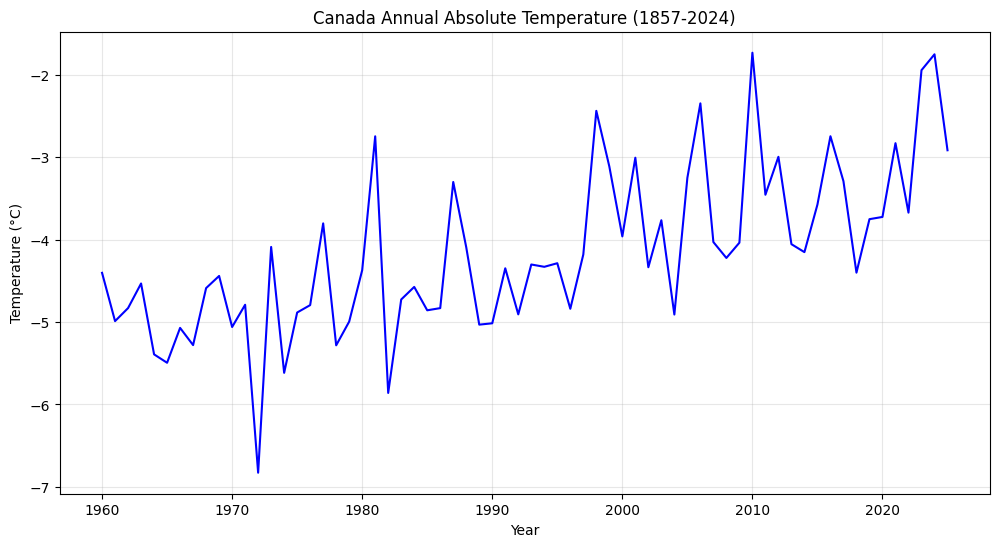

In [8]:
plt.figure(figsize=(12, 6))                  # Set figure size for better visibility of long-term trend
plt.plot(annual_anomalies.index,             # Year on x-axis
         annual_anomalies["Absolute_Temperature"],      # Clear blue line for temperature trend
         linewidth=1.5, color='blue')                   # Clear blue line for temperature trend
plt.title("Canada Annual Absolute Temperature (1857-2024)")
plt.xlabel("Year")
plt.ylabel("Temperature (°C)")
plt.grid(True, alpha=0.3)
plt.show()                                              # Light grid for easier reading of values

**7. (3 pts) – Load global CO₂ concentration data**

Download the global average annual CO₂ concentrations dataset from [the NOAA web site](https://gml.noaa.gov/ccgg/trends/gl_data.html).
Load this dataset into Python.

*Remember to upload the dataset separately to Brightspace.*

In [9]:
CO2_data = pd.read_fwf("co2_annmean_gl.txt",
                    skiprows=39,
                    widths=[6,9],
                    names=["Year","mean"],
                    index_col="Year"
                      )
print("CO2 data loaded:")
display(CO2_data)

CO2 data loaded:


,mean
Year,
1979,336.85
1980,338.91
1981,340.11
1982,340.86
1983,342.53
1984,344.07
1985,345.54
1986,346.97
1987,348.68


**8. (5 pts) – Combine temperature and CO₂ data**

Create a single dataset that contains both:
- The average annual CO₂ concentrations (ppm).
- Your country’s average annual absolute temperatures.

In [10]:
Temp_vs_CO2 = pd.merge(annual_anomalies,  # Canada's annual temperature data
                       CO2_data,          # Global CO2 concentrations dataset
                       on="Year")         # Merge using Year as common key
display (Temp_vs_CO2)                     # Show merged dataframe to verify successful integration

,Anomaly,Absolute_Temperature,mean
Year,,,
1979,-0.135083,-4.995083,336.85
1980,0.488750,-4.371250,338.91
1981,2.113667,-2.746333,340.11
1982,-1.000917,-5.860917,340.86
1983,0.133417,-4.726583,342.53
1984,0.285917,-4.574083,344.07
1985,0.002083,-4.857917,345.54
1986,0.028500,-4.831500,346.97
1987,1.559167,-3.300833,348.68


**9. (6 pts) – Plot temperature vs. CO₂**

Make a plot with your country’s average annual absolute temperatures on the x-axis and the global average annual CO₂ concentrations (ppm) on the y-axis.
Include only years for which both datasets have values.

*Make sure your plot is clear, well-labelled, and visually suitable for inclusion in your report.*

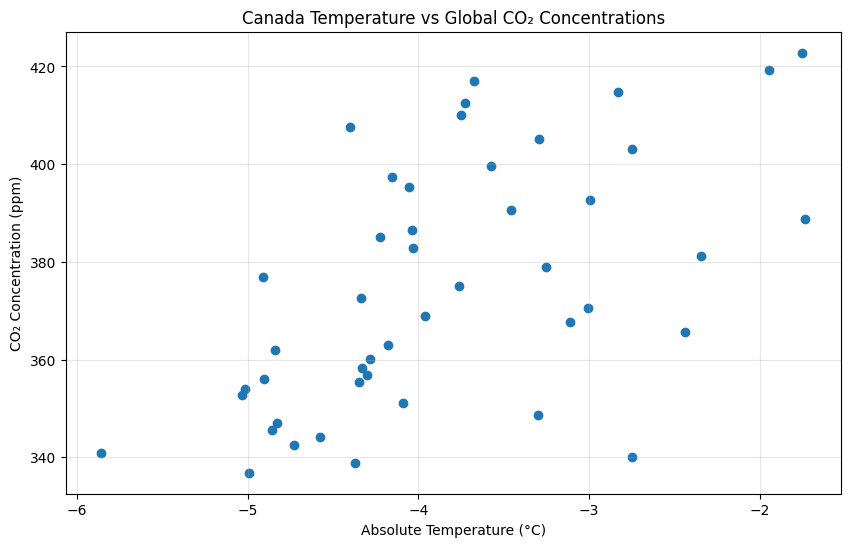

In [11]:
x=Temp_vs_CO2["Absolute_Temperature"]  # Canada's annual average temperatures
y=Temp_vs_CO2["mean"]                  # Global annual CO2 concentrations (ppm)
plt.figure(figsize=(10, 6))
plt.xlabel("Absolute Temperature (°C)")
plt.ylabel("CO₂ Concentration (ppm)")
plt.title("Canada Temperature vs Global CO₂ Concentrations")
plt.grid(True, alpha=0.3)              # Subtle grid for better readability
plt.scatter(x,y)                       # Scatter plot to show correlation
plt.show()

## Question 2: Trend analysis and visualization (30 pts)

### Learning goals
- Use Python to perform statistical calculations on time series data.
- Visualize multiple datasets and model results in a single, clear plot.

### Tasks (1-6):

**1. (4 pts) – Calculate an 11-year running mean**

- Calculate the 11-year running mean of your temperature data. 
- For example, the the value for 2000 should be the average over 1995–2005.
- Exclude the first 5 years and last 5 years from the result, as there is not enough data before/after these years to calculate a centered 11-year mean.

In [12]:
Temperatures=pd.DataFrame({"temperatures":annual_anomalies["Absolute_Temperature"],})

df_1960 = pd.DataFrame({"11yr_running_mean":Temperatures["temperatures"].rolling(window=11, center=True).mean()},index=range(1960,2025))
display(df_1960[5:-5])

,11yr_running_mean
1965,-4.916910
1966,-4.952136
1967,-5.119394
1968,-5.051924
1969,-5.150485
1970,-5.104318
1971,-5.040697
1972,-4.925402
1973,-4.925629
1974,-4.962576


**2. (4 pts) – Calculate decadal averages**

- Calculate the average temperature for each decade, using only the values within that decade (e.g., 1960–1969 for the 1960s).
- Exclude incomplete decades from your results.

In [13]:
annual_anomalies["Decade"] = (annual_anomalies.index // 10) * 10
decadal_avg = annual_anomalies.groupby("Decade")["Absolute_Temperature"].mean().reset_index()

print("Decadal averages:")
display(decadal_avg.tail(10))

Decadal averages:


,Decade,Absolute_Temperature
0,1960,-4.902535
1,1970,-5.014733
2,1980,-4.439458
3,1990,-4.175975
4,2000,-3.786433
5,2010,-3.415542
6,2020,-2.806299


**3. (4 pts) – Compare decadal averages to the 2010s**

For each decadal average after the 1960s (e.g., 1970s, 1980s, …, 2010s):
- Draw the line between that decade’s average and the 1960s average.
- Extend this line across the entire data range.
- Visually assess which line best fits the annual temperature data.

Rationale: This shows how different decades imply different warming trends and helps identify which trajectory best matches the observed annual data.

**Hint**: When averaging over a decade, use the midpoint year of that decade as the $x$-coordinate for the plotted point.

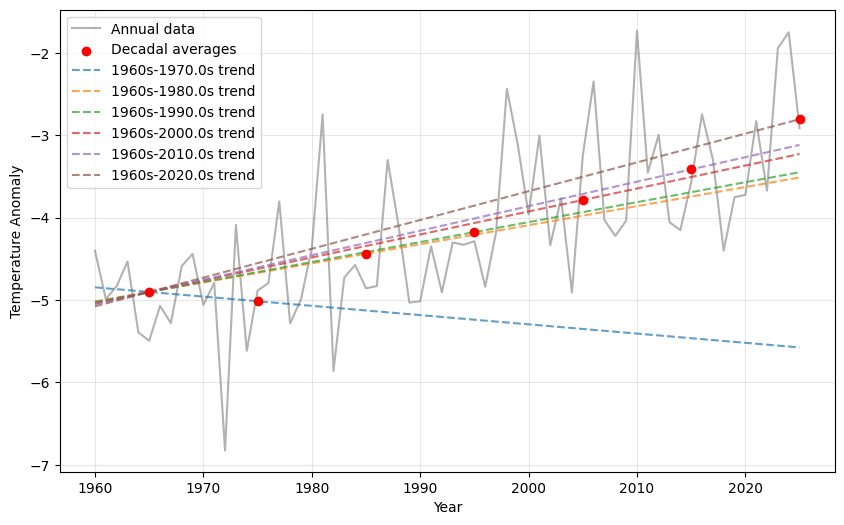

In [14]:
midpoints = decadal_avg["Decade"] + 5
ref_decade = 1960
x0 = ref_decade + 5
y0 = decadal_avg[decadal_avg["Decade"] == ref_decade]["Absolute_Temperature"].values[0]
plt.figure(figsize=(10,6))
plt.plot(df_average.index, df_average["Temperature"], color="gray", alpha=0.6, label="Annual data")
plt.scatter(midpoints, decadal_avg["Absolute_Temperature"], color="red", zorder=5, label="Decadal averages")

for index, row in decadal_avg.iterrows():
    decade = row["Decade"]
    if decade > 1960:
        x_decade = decade + 5
        y_decade = row["Absolute_Temperature"]
        slope = (y_decade - y0) / (x_decade - x0)
        intercept = y0 - slope * x0
        x_range = np.array([df_average.index.min(), df_average.index.max()])
        y_line = slope * x_range + intercept
        plt.plot(x_range, y_line, linestyle='--', alpha=0.7, label=f'1960s-{decade}s trend')
        
plt.xlabel("Year")
plt.ylabel("Temperature Anomaly")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

**4. (4 pts) – Analyse the best-fitting decadal line**

For the decadal fit you identified as the best in Task 3:
- Compute the predicted annual values (fit values) for the period 1960–2024.
- Calculate the predicted value for 2050.
- Compute the Percent Bias (PBIAS) and the Normalised Root Mean Square Error (NRMSE).

In [15]:
import numpy as np
from sklearn.metrics import mean_squared_error

# Use available years from df_average and drop NaN values
df_clean = df_average.dropna()
available_years = df_clean.index
start_year, end_year = available_years.min(), available_years.max()

# Use first and last available years for regression
X_ref = start_year
Y_ref = df_clean.loc[start_year, "Temperature"]

X_recent = end_year
Y_recent = df_clean.loc[end_year, "Temperature"]

# Linear regression
slope = (Y_recent - Y_ref) / (X_recent - X_ref)
intercept = Y_ref - slope * X_ref

# Predictions for 1960-2024
years = np.arange(1960, 2025)
predicted_values = slope * years + intercept

# Actual values for comparison - only use years that exist in clean data
valid_years = [year for year in years if year in df_clean.index]
actual_values = df_clean.loc[valid_years, "Temperature"].values
predicted_values_filtered = slope * np.array(valid_years) + intercept

# Metrics
mse = mean_squared_error(actual_values, predicted_values_filtered)
rmse = np.sqrt(mse)
nrmse = rmse / (actual_values.max() - actual_values.min())

pbas = np.mean((predicted_values_filtered - actual_values) / actual_values) * 100

# Prediction for 2050
predicted_2050 = slope * 2050 + intercept

print(f"Predicted value for 2050: {predicted_2050:.2f}")
print(f"Percent Bias (pbas): {pbas:.2f}%")
print(f"Normalized Root Mean Square Error (NRMSE): {nrmse:.4f}")

Predicted value for 2050: -2.34
Percent Bias (pbas): -7.20%
Normalized Root Mean Square Error (NRMSE): 0.1820


**5. (6 pts) – Linear regression model**

- Perform a linear regression on the annual average temperature data.
- Calculate the model values for the period 1960-2024.
- Determine the predicted value for 2050.
- Compute the PBIAS and the Normalised Root Mean Square Error (NRMSE) for the linear regression model.

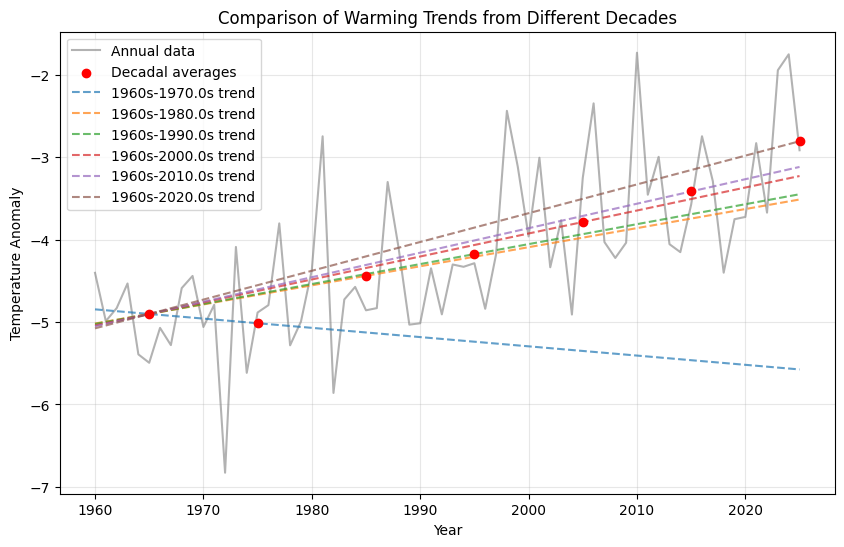

In [16]:
ref_decade = 1960
x_ref = ref_decade + 5  # Midpoint of reference decade
y_ref = decadal_avg.loc[decadal_avg["Decade"] == ref_decade, "Absolute_Temperature"].values[0]

# Create the plot
plt.figure(figsize=(10,6))
plt.plot(df_average.index, df_average["Temperature"], color="gray", alpha=0.6, label="Annual data")

# Plot decadal averages as points
decadal_midpoints = decadal_avg["Decade"] + 5
plt.scatter(decadal_midpoints, decadal_avg["Absolute_Temperature"], color="red", zorder=5, label="Decadal averages")

# For each decade after the 1960s, draw a line to the 1960s and extend it
recent_decades = decadal_avg[decadal_avg["Decade"] > ref_decade]

for i, row in recent_decades.iterrows():
    decade = row["Decade"]
    x_decade = decade + 5  # Midpoint of current decade
    y_decade = row["Absolute_Temperature"]
    
    # Calculate slope and intercept for the line
    slope = (y_decade - y_ref) / (x_decade - x_ref)
    intercept = y_ref - slope * x_ref
    
    # Create x-values spanning the entire data range
    x_range = np.array([df_average.index.min(), df_average.index.max()])
    y_line = slope * x_range + intercept
    
    # Plot the line
    plt.plot(x_range, y_line, linestyle='--', alpha=0.7, 
             label=f'{ref_decade}s-{decade}s trend')

# Add labels and legend
plt.xlabel("Year")
plt.ylabel("Temperature Anomaly")
plt.title("Comparison of Warming Trends from Different Decades")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

**6. (8 pts) – Plot in a single figure:**

Plot, in a single figure:
- the annual temperature data,
- the 11-year running mean,
- the decadal averages,
- your best decadal fit line, and
- the linear regression line.
  
*Include clear axis labels and a legend.*

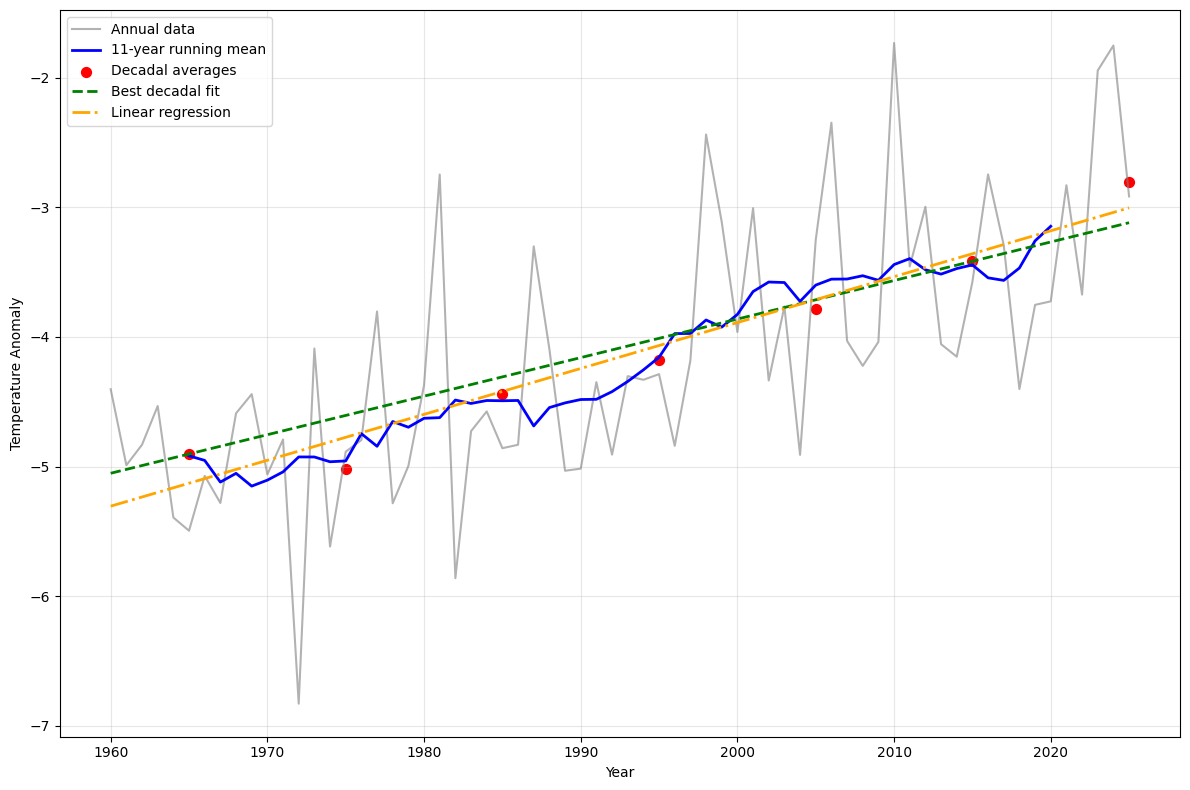

In [17]:
import numpy as np
from scipy import stats

df_average['Temperature'] = pd.to_numeric(df_average['Temperature'], errors='coerce')
df_average['11yr_running_mean'] = df_average['Temperature'].rolling(11, center=True).mean()

slope, intercept, _, _, _ = stats.linregress(df_average.index, df_average['Temperature'])

x_ref, y_ref = 1965, decadal_avg.loc[decadal_avg["Decade"] == 1960, "Absolute_Temperature"].values[0]
x_recent, y_recent = 2015, decadal_avg.loc[decadal_avg["Decade"] == 2010, "Absolute_Temperature"].values[0]

slope_best = (y_recent - y_ref) / (x_recent - x_ref)
intercept_best = y_ref - slope_best * x_ref

plt.figure(figsize=(12,8))

plt.plot(df_average.index, df_average["Temperature"], 'gray', alpha=0.6, label="Annual data")
plt.plot(df_average.index, df_average['11yr_running_mean'], 'blue', linewidth=2, label="11-year running mean")

midpoints = decadal_avg["Decade"] + 5
plt.scatter(midpoints, decadal_avg["Absolute_Temperature"], c="red", s=50, label="Decadal averages")

x_range = [df_average.index.min(), df_average.index.max()]
plt.plot(x_range, slope_best * np.array(x_range) + intercept_best, 'g--', linewidth=2, label="Best decadal fit")
plt.plot(x_range, intercept + slope * np.array(x_range), 'orange', linestyle='-.', linewidth=2, label="Linear regression")

plt.xlabel("Year")
plt.ylabel("Temperature Anomaly")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Question 3: Radiative forcing (20 pts)

### Learning goals

- Perform calculations using scientific formulas in Python.
- Create and manipulate two-dimensional data structures.

### Tasks (1-3):

The equations from the lecture relate the absorbed fraction $f$ to the albedo $A$ and the temperature $T$ (**in K**), as

$$ f = 2 - \frac{C_{\text{sol}}(1 - A)}{2 \sigma T^4} $$

where $C_{\text{sol}} = 1361 \text{W}/\text{m}^2$ and $\sigma = 5.67 \cdot 10^{-8} \text{W}/(\text{m}^2 \cdot \text{K})$.

**1. (10 pts) – Using your annual average temperatures, compute the absorbed fraction for albedos from 0.20 to 0.40 (inclusive) in steps of 0.025**

The result should be a two-dimensional table (e.g., a Pandas DataFrame) with:
- Albedo values as column headers.
- Temperatures as row indices.
- Absorbed fractions as table elements.

In [18]:
import numpy as np
import pandas as pd

C_sol = 1361
sigma = 5.67e-8
albedos = [round(a,3) for a in 
           [0.20 + i*0.025 for i in range(int((0.40-0.20)/0.025)+1)]]      #inside of range() we calculate the amount of numbers within that range

temps_C = annual_anomalies.loc[1960:2024, "Absolute_Temperature"].tolist()                #turns column of dataframe into list
temps_K = [t + 273.15 for t in temps_C]                                    #turns ºC into K, for every element in temps_C

data = []
for T in temps_K:
    row = []
    for A in albedos:
        f = 2 - (C_sol * (1 - A)) / (2 * sigma * (T**4))
        row.append(f)                                                       #add f to row
    data.append(row)                                                        #add row to data list

df_fractions = pd.DataFrame(
    data,                                                                   #says what data is included in the df
    columns=albedos,                                                        #says how many and which are the columns
    index=range(1960,2025))                                                 #calls the index

df_fractions["Yearly Temperature"] = annual_anomalies.loc[1960:2024, "Absolute_Temperature"]

df_fractions.index.name = "Year"

cols = ["Yearly Temperature"] + [c for c in df_fractions.columns if c != "Yearly Temperature"]
df_fractions = df_fractions[cols]

display(df_fractions.head())

,Yearly Temperature,0.2,0.225,0.25,0.275,0.3,0.325,0.35,0.375,0.4
Year,,,,,,,,,,
1960,-4.403182,0.159390,0.216909,0.274428,0.331947,0.389466,0.446985,0.504505,0.562024,0.619543
1961,-4.989333,0.143244,0.201268,0.259292,0.317315,0.375339,0.433362,0.491386,0.549410,0.607433
1962,-4.831167,0.147619,0.205505,0.263392,0.321279,0.379166,0.437053,0.494940,0.552827,0.610714
1963,-4.532500,0.155843,0.213473,0.271103,0.328733,0.386363,0.443993,0.501623,0.559252,0.616882
1964,-5.392750,0.132029,0.190403,0.248777,0.307151,0.365525,0.423900,0.482274,0.540648,0.599022


**2. (3 pts) – Check and cap absorbed fractions**

- Check if any absorbed fraction values are greater than 1. 
- If so, identify the corresponding $(A, T)$ combinations.
- Replace any fractions above 1 with 1.
- If no values exceed 1, still perform the operations.

In [19]:
df_fractions2 = df_fractions.drop("Yearly Temperature", axis=1)

df_fractions2 = df_fractions2.clip(upper=1)                           #switches every value over 1 to 1

display(df_fractions2)

,0.2,0.225,0.25,0.275,0.3,0.325,0.35,0.375,0.4
Year,,,,,,,,,
1960,0.159390,0.216909,0.274428,0.331947,0.389466,0.446985,0.504505,0.562024,0.619543
1961,0.143244,0.201268,0.259292,0.317315,0.375339,0.433362,0.491386,0.549410,0.607433
1962,0.147619,0.205505,0.263392,0.321279,0.379166,0.437053,0.494940,0.552827,0.610714
1963,0.155843,0.213473,0.271103,0.328733,0.386363,0.443993,0.501623,0.559252,0.616882
1964,0.132029,0.190403,0.248777,0.307151,0.365525,0.423900,0.482274,0.540648,0.599022
...,...,...,...,...,...,...,...,...,...
2020,0.177855,0.234797,0.291739,0.348681,0.405623,0.462565,0.519507,0.576449,0.633391
2021,0.201878,0.258069,0.314261,0.370452,0.426643,0.482835,0.539026,0.595217,0.651409
2022,0.179268,0.236166,0.293063,0.349961,0.406859,0.463757,0.520655,0.577553,0.634451


**3. (7 pts) – Radiative forcing calculation**

For each albedo value, calculate the radiative forcing over the period 1960-2024. 

You should end up with 9 radiative forcing values in total (one per albedo value, not per temperature). 

Radiative forcing can be calculated using the equation:

$$ \Delta F = \Delta T_E \cdot 4 \left( 1 - \frac{f}{2} \right) \sigma T_E^3 $$

where:
- $\Delta T_E$ is the temperature difference over the entire interval (in K)
- $T_E$ can be assumed to be the temperature at the start of the interval (in K).
- $f$ = albedo,
- $\sigma$ = Stefan–Boltzmann constant.

In [20]:
# FIXED: delta_T_E was hardcoded to 1.5 -- using the actual computed warming
# over the interval instead. Also fixed `temps[0]` (undefined) -> temps_K[0]
# (temps_K is in Kelvin, as required by the Stefan-Boltzmann formula).
delta_T_E = temps_K[-1] - temps_K[0]  # real warming 1960->2024, in K
T_E = temps_K[0]  # reference temperature; using start-of-period value in Kelvin

radiative_forcing = delta_T_E * 4 * (1 - df_fractions2.mean() / 2) * sigma * T_E**3
Radiative_force1=pd.DataFrame({
    "Radiative Forcing":radiative_forcing}, index=albedos)
display(Radiative_force1)

,Radiative Forcing
0.200,10.709157
0.225,10.374496
0.250,10.039835
0.275,9.705174
0.300,9.370513
0.325,9.035851
0.350,8.701190
0.375,8.366529
0.400,8.031868


## Readable and clean code (10 pts)
Your final code should be easy to read, understand, and reproduce. Review basic clean-code practices and apply them throughout your notebook. 

Key aspects include:

- clear, descriptive variable and function names;
- concise and informative comments.
- logical organisation and use of code cells;
- avoid excessive or unnecessary print statements and plots;
- minimise repetition by reusing code where appropriate.

## Report (40% of Assignment 1 grade)
You will write a report summarising your findings.
Separate instructions for the report will be provided on Brightspace.